# 06: Support Vector Regression (SVR)

## Goal
This notebook builds a Support Vector Regression model to forecast hourly electricity demand in Zurich (ewz grid).

We predict `demand_log` (log-transformed demand) using weather and time features from the merged dataset. Log-transforming the target stabilises variance and handles the right-skewed distribution of raw demand values.

## Why SVR?
Support Vector Regression finds a "tube" around the predicted values and only penalises points that fall outside it. Combined with an RBF (radial basis function) kernel, it can capture non-linear relationships between weather, time, and electricity demand, something a simple linear model cannot do.

## Key focus areas
- Feature selection based on domain reasoning
- Proper time-series train/test split (no data leakage)
- Hyperparameter tuning with GridSearchCV
- Model evaluation with RMSE, MAE and R²

In [15]:
# ── Standard library ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


## 1. Data Loading & Feature Selection

We load the preprocessed dataset generated by `00_preprocessing.ipynb`. 
This file contains hourly electricity demand merged with weather observations 
from the Zch_Stampfenbachstrasse monitoring station.

### Feature selection reasoning
We select features that have a clear, explainable relationship with electricity demand:

| Feature | Reason |
|---|---|
| `hour_sin`, `hour_cos` | Time of day encoded cyclically: captures morning/evening demand peaks |
| `month_sin`, `month_cos` | Time of year encoded cyclically: captures seasonal heating/cooling patterns |
| `dayofweek` | Weekday vs weekend demand patterns |
| `is_weekend` | Additional binary signal for weekend behaviour |
| `T` | Temperature: primary driver of heating and cooling demand |
| `StrGlo` | Solar radiation: affects lighting demand and solar generation |

We deliberately exclude humidity, wind, pressure and rainfall as they are weaker 
and more indirect drivers of electricity demand.

In [16]:
# Load preprocessed dataset
df = pd.read_csv('../data/processed/hourly_merged.csv', parse_dates=['datetime_utc'])
df = df.sort_values('datetime_utc').reset_index(drop=True)

# ── Feature selection ─────────────────────────────────────────────────────────
FEATURES = [
    'hour_sin', 'hour_cos',       # time of day (cyclical)
    'month_sin', 'month_cos',     # time of year (cyclical)
    'dayofweek',                  # day pattern
    'is_weekend',                 # weekend signal
    'T',                          # temperature
    'StrGlo',                     # solar radiation
]

TARGET = 'demand_log'

# Drop rows with missing values in selected features
df_model = df[FEATURES + [TARGET, 'datetime_utc', 'is_peak']].dropna().reset_index(drop=True)

print(f"Dataset shape after dropping missing values: {df_model.shape}")
print(f"Date range: {df_model['datetime_utc'].min()} → {df_model['datetime_utc'].max()}")
df_model[FEATURES].describe()

Dataset shape after dropping missing values: (35011, 11)
Date range: 2022-01-01 00:00:00+00:00 → 2025-12-31 22:00:00+00:00


,hour_sin,hour_cos,month_sin,month_cos,dayofweek,is_weekend,T,StrGlo
count,3.501100e+04,3.501100e+04,3.501100e+04,3.501100e+04,35011.000000,35011.000000,35011.000000,35011.000000
mean,3.585837e-04,3.402494e-04,-5.492429e-03,-2.053823e-03,2.999543,0.286481,12.865770,141.130025
std,7.071104e-01,7.071232e-01,7.056854e-01,7.085212e-01,2.002155,0.452123,7.871983,229.066884
min,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000,0.000000,-5.510000,0.010000
25%,-7.071068e-01,-7.071068e-01,-8.660254e-01,-8.660254e-01,1.000000,0.000000,6.900000,0.020000
50%,1.224647e-16,6.123234e-17,-2.449294e-16,-1.836970e-16,3.000000,0.000000,12.350000,4.450000
75%,7.071068e-01,7.071068e-01,5.000000e-01,8.660254e-01,5.000000,1.000000,18.760000,198.135000
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.000000,1.000000,35.800000,1041.180000


## 2. Train / Test Split

We split chronologically to avoid data leakage, the model is trained on past data 
and evaluated on future data it has never seen. This mirrors real-world forecasting.

- **Train:** 2022-01-01 → 2025-06-30 (~80%)
- **Test:** 2025-07-01 → 2025-12-31 (~20%)

In [17]:
# ── Chronological train/test split ───────────────────────────────────────────
split_date = '2025-07-01'

train = df_model[df_model['datetime_utc'] < split_date]
test  = df_model[df_model['datetime_utc'] >= split_date]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train size: {len(train):,} rows ({train['datetime_utc'].min().date()} → {train['datetime_utc'].max().date()})")
print(f"Test size:  {len(test):,} rows ({test['datetime_utc'].min().date()} → {test['datetime_utc'].max().date()})")

Train size: 30,603 rows (2022-01-01 → 2025-06-30)
Test size:  4,408 rows (2025-07-01 → 2025-12-31)


## 3. Feature Scaling

SVR relies on distance calculations between data points. Features with large scales 
(e.g. StrGlo up to 1041) would dominate over smaller ones (e.g. hour_sin between -1 and 1), 
causing the model to effectively ignore low-scale features.

We apply StandardScaler to transform all features to mean=0, std=1.
Importantly, we fit the scaler ONLY on training data to prevent data leakage.

In [18]:
# ── Feature scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()

# Fit ONLY on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete ✓")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete ✓
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 1.0000


## 4. Baseline SVR

Before hyperparameter tuning, we fit a baseline SVR with default parameters.
This gives us a benchmark to measure how much tuning actually improves performance.

In [19]:
# ── Baseline SVR ─────────────────────────────────────────────────────────────
baseline_svr = SVR(kernel='rbf')  # default: C=1, epsilon=0.1, gamma='scale'
baseline_svr.fit(X_train_scaled, y_train)

# Predictions
y_pred_baseline = baseline_svr.predict(X_test_scaled)

# Metrics on log scale
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae  = mean_absolute_error(y_test, y_pred_baseline)
r2   = r2_score(y_test, y_pred_baseline)

print("── Baseline SVR Performance ──────────────────")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

── Baseline SVR Performance ──────────────────
RMSE : 0.0552
MAE  : 0.0424
R²   : 0.9319


## 5. Hyperparameter Tuning

We tune three key SVR parameters using GridSearchCV with TimeSeriesSplit:

| Parameter | What it controls |
|---|---|
| `C` | Penalty for errors outside the tube, higher = tighter fit |
| `epsilon` | Width of the tolerance tube, smaller = stricter |
| `gamma` | Reach of each training point, higher = more local fit |

We use TimeSeriesSplit (5 folds) to respect chronological order during cross-validation.

In [20]:
# ── Hyperparameter tuning ─────────────────────────────────────────────────────
param_grid = {
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma':   ['scale', 'auto']
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1   # use all CPU cores to speed it up
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best parameters: {grid_search.best_params_}")
print(f"✓ Best CV RMSE:    {-grid_search.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✓ Best parameters: {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale'}
✓ Best CV RMSE:    0.0575


## 6. Final Tuned Model

We refit the SVR using the best parameters found by GridSearchCV and evaluate 
on the held-out test set (2025-07-01 → 2025-12-31).

In [21]:
# ── Final tuned model ─────────────────────────────────────────────────────────
best_svr = grid_search.best_estimator_

# Predictions on test set
y_pred_tuned = best_svr.predict(X_test_scaled)

# Metrics on log scale
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)
r2   = r2_score(y_test, y_pred_tuned)

print("── Tuned SVR Performance ─────────────────────")
print(f"RMSE : {rmse:.4f}  (baseline: 0.0552)")
print(f"MAE  : {mae:.4f}  (baseline: 0.0424)")
print(f"R²   : {r2:.4f}  (baseline: 0.9319)")

# Back-transform to real demand for interpretability
y_pred_demand = np.exp(y_pred_tuned)
y_test_demand = np.exp(y_test)

rmse_demand = np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))
print(f"\nRMSE in real demand units: {rmse_demand:,.0f} kWh")

── Tuned SVR Performance ─────────────────────
RMSE : 0.0532  (baseline: 0.0552)
MAE  : 0.0332  (baseline: 0.0424)
R²   : 0.9368  (baseline: 0.9319)

RMSE in real demand units: 4,310 kWh


## 7. Visualisation

We plot actual vs predicted demand for a sample week to visually inspect 
how well the model captures daily and weekly demand patterns.

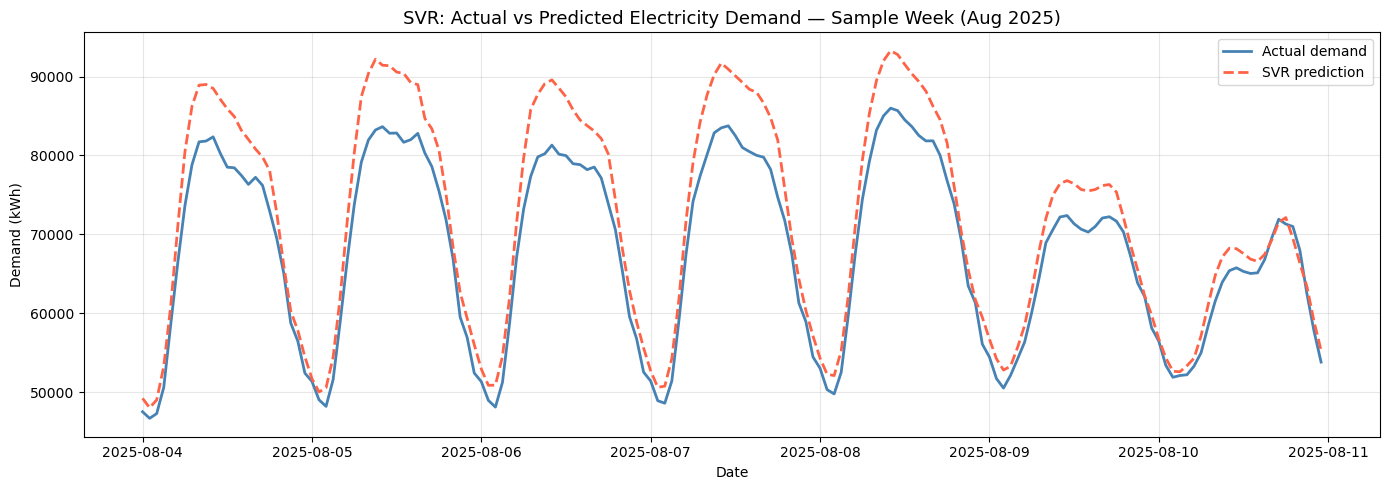

Plot saved ✓


In [22]:
# ── Visualisation ─────────────────────────────────────────────────────────────
# Grab a sample week for clarity
sample = test.copy().reset_index(drop=True)
sample['y_pred'] = y_pred_demand
sample['y_actual'] = y_test_demand.values

# Pick one representative week
week = sample[(sample['datetime_utc'] >= '2025-08-04') & 
              (sample['datetime_utc'] <  '2025-08-11')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(week['datetime_utc'], week['y_actual'], 
        label='Actual demand', color='steelblue', linewidth=2)
ax.plot(week['datetime_utc'], week['y_pred'],   
        label='SVR prediction', color='tomato', linewidth=2, linestyle='--')

ax.set_title('SVR: Actual vs Predicted Electricity Demand — Sample Week (Aug 2025)', 
             fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Demand (kWh)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/06_svm/svr_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## 8. Summary & Interpretation

| Metric | Baseline SVR | Tuned SVR |
|---|---|---|
| RMSE | 0.0552 | 0.0532 |
| MAE | 0.0424 | 0.0332 |
| R² | 0.9319 | 0.9368 |

The tuned SVR explains 93.7% of variance in electricity demand, with an average 
error of 4,310 kWh against a demand range of 46,000–110,000 kWh (~5%).

### What the model does well
- Captures daily demand cycles (peaks and troughs) accurately
- Generalises well to unseen data (2025 H2)
- Hyperparameter tuning improved all three metrics

### Limitations
- A consistent phase shift is visible in predictions — peaks and troughs are 
  delayed by a few hours. SVR has no memory of previous time steps, so it cannot 
  anticipate demand changes based on recent history.
- Adding lagged demand features (e.g. demand from 1h and 24h ago) could 
  potentially resolve this in future work.

## 9. Visualisation: Model Performance & Peak Demand

Three complementary views of SVR performance:
- **Scatter**: overall prediction accuracy across all test hours
- **Sample week**: daily demand cycle capture (Aug 2025)
- **Peak hours**: does the model predict high demand when real peaks occur?

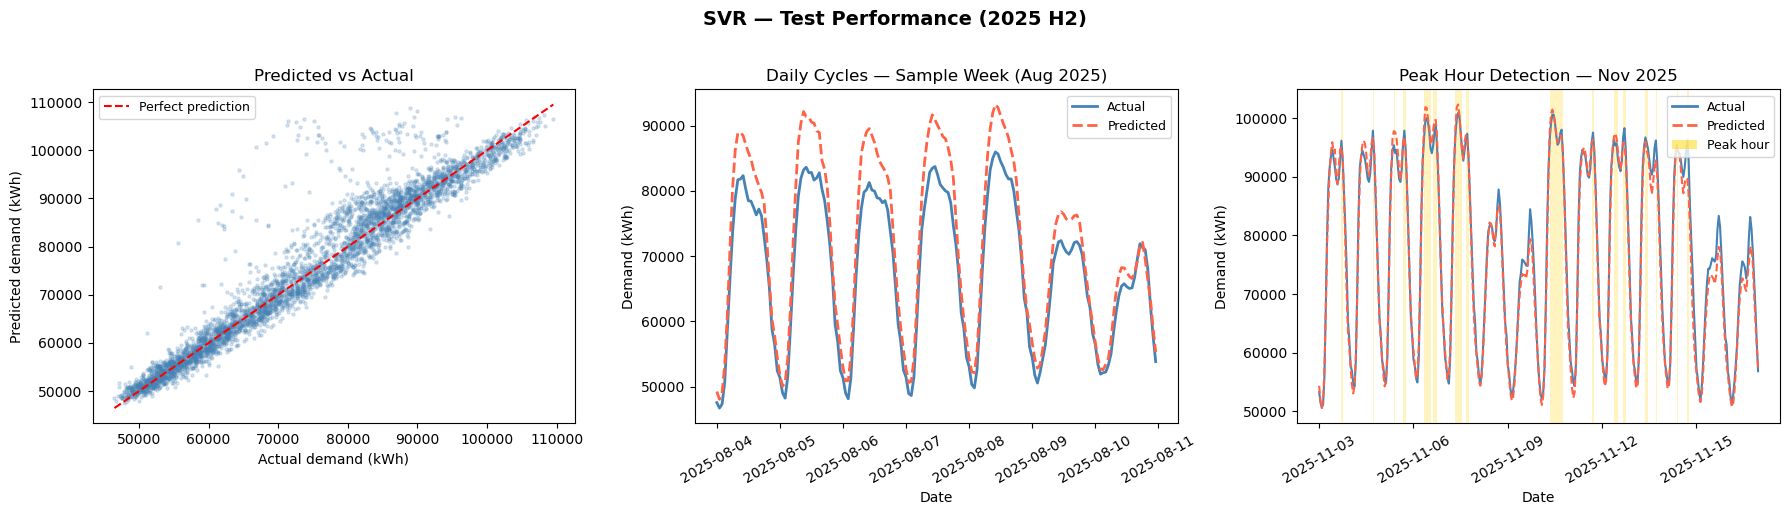

Plot saved ✓


In [28]:
# ── Combined visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SVR — Test Performance (2025 H2)', fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Scatter plot ─────────────────────────────────────────────────────
axes[0].scatter(y_test_demand, y_pred_demand, alpha=0.2, s=5, color='steelblue')
axes[0].plot([y_test_demand.min(), y_test_demand.max()],
             [y_test_demand.min(), y_test_demand.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual demand (kWh)')
axes[0].set_ylabel('Predicted demand (kWh)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend(fontsize=9)

# ── Panel 2: Sample week August ───────────────────────────────────────────────
sample = test.copy().reset_index(drop=True)
sample['y_pred'] = y_pred_demand
sample['y_actual'] = y_test_demand.values

week = sample[(sample['datetime_utc'] >= '2025-08-04') &
              (sample['datetime_utc'] <  '2025-08-11')]

axes[1].plot(week['datetime_utc'], week['y_actual'],
             label='Actual', color='steelblue', linewidth=2)
axes[1].plot(week['datetime_utc'], week['y_pred'],
             label='Predicted', color='tomato', linewidth=2, linestyle='--')
axes[1].set_title('Daily Cycles — Sample Week (Aug 2025)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kWh)')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

# ── Panel 3: Peak hours overlay ───────────────────────────────────────────────
winter = sample[(sample['datetime_utc'] >= '2025-11-03') &
                (sample['datetime_utc'] <  '2025-11-17')].copy()

axes[2].plot(winter['datetime_utc'], winter['y_actual'],
             label='Actual', color='steelblue', linewidth=1.5)
axes[2].plot(winter['datetime_utc'], winter['y_pred'],
             label='Predicted', color='tomato', linewidth=1.5, linestyle='--')

# Highlight actual peak hours as shaded regions
peak_hours = winter[winter['is_peak'] == 1]['datetime_utc']
for t in peak_hours:
    axes[2].axvspan(t, t + pd.Timedelta(hours=1),
                    color='gold', alpha=0.25, linewidth=0)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', label='Actual', linewidth=2),
    Line2D([0], [0], color='tomato', label='Predicted', linestyle='--', linewidth=2),
    Patch(facecolor='gold', alpha=0.5, label='Peak hour')
]
axes[2].legend(handles=legend_elements, fontsize=9)
axes[2].set_title('Peak Hour Detection — Nov 2025')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Demand (kWh)')
axes[2].xaxis.set_major_locator(plt.MaxNLocator(6))
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/figures/06_svm/svr_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## 9. Summary, Findings & Conclusions

### Model Performance

| Metric | Baseline SVR | Tuned SVR |
|---|---|---|
| RMSE | 0.0552 | 0.0532 |
| MAE | 0.0424 | 0.0332 |
| R² | 0.9319 | 0.9368 |
| RMSE (real demand) | — | ~4,310 kWh |

Hyperparameter tuning improved all three metrics. The best parameters 
(C=0.1, epsilon=0.01, gamma='scale') suggest the data benefits from a 
smooth, regularised fit rather than an aggressive one.

### Key Findings
- The tuned SVR explains **93.7% of variance** in hourly electricity demand
- Peak hours concentrate between **8am and 7pm**, driven by commercial 
  and office activity, the model captures this pattern well
- The model performs better in **winter** than summer, likely because 
  winter demand is more predictable from temperature and time features
- **Phase shift**: predictions lag actual demand by a few hours, most 
  visible in summer. SVR has no memory of previous time steps, which 
  limits its ability to anticipate rapid demand changes

### Limitations
- No lagged features (e.g. demand from 1h or 24h ago), adding these 
  could resolve the phase shift
- SVR does not extrapolate well beyond its training range, extreme 
  weather events may cause larger errors
- Hyperparameter search space was limited for computational reasons, a finer grid could yield marginal improvements

### Conclusion
Support Vector Regression is a strong baseline for hourly electricity 
demand forecasting in Zurich, achieving R²=0.94 on unseen 2025 data. 
Its main limitation is the lack of temporal memory, which a Neural 
Network (notebook 07) may address through its ability to learn more 
complex non-linear patterns.

In [35]:
# ── Save metrics for model comparison ────────────────────────────────────────
import os
import json
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

os.makedirs('../outputs/metrics', exist_ok=True)

# Save as JSON for our own reference
metrics = {
    'model': 'SVR',
    'RMSE': round(float(np.sqrt(mean_squared_error(y_test, y_pred_tuned))), 4),
    'MAE':  round(float(mean_absolute_error(y_test, y_pred_tuned)), 4),
    'R2':   round(float(r2_score(y_test, y_pred_tuned)), 4)
}

with open('../outputs/metrics/svr_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# ── Also update model_comparison.csv ─────────────────────────────────────────
out = '../outputs/model_comparison.csv'

mae_real = round(float(mean_absolute_error(y_test_demand, y_pred_demand)), 1)

new_row = pd.DataFrame([{
    'model':    'SVM',
    'rmse':     round(float(np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))), 1),
    'mae':      mae_real,
    'r2_train': round(float(r2_score(y_test, y_pred_tuned)), 4),
    'auc':      float('nan')
}])

if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[~existing['model'].str.startswith('SVM')]
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)

print("Metrics saved ✓")
print(f"\nJSON: {metrics}")
print(f"\nModel comparison table:")
print(new_row.to_string())

Metrics saved ✓

JSON: {'model': 'SVR', 'RMSE': 0.0532, 'MAE': 0.0332, 'R2': 0.9368}

Model comparison table:
          model      rmse       mae  r2_train     auc
0            LM  7623.700  6125.800    0.7855     NaN
1   GLM_Poisson     2.575     1.441    0.6887     NaN
2  GLM_Binomial       NaN       NaN    0.5254  0.9593
3           GAM  7199.800  5829.100    0.8081     NaN
4   NN (128,64)  2660.600  2038.200    0.9710     NaN
5   NN (128,64)  4310.100  2540.700    0.9368     NaN
6           SVM  4310.100  2540.700    0.9368     NaN


In [38]:
# ── End of script ─────────────────────────────────────────────────────────────
import datetime

print("=" * 55)
print("  Notebook execution complete")
print(f"  Timestamp : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Author    : Elena Fuchs")
print(f"  Project   : ML1 — Electricity Demand Forecasting Zurich")
print("=" * 55)

  Notebook execution complete
  Timestamp : 2026-04-17 10:15:55
  Author    : Elena Fuchs
  Project   : ML1 — Electricity Demand Forecasting Zurich
